# Fit and visualize a Doohan hierarchical LMDP

This notebook reproduces the data setup and trial assembly from `doohan_trial_lmdp.ipynb`, fits a fresh distributed hierarchy to those trials with Adam, materializes the best parameter snapshot as a new NumPy hierarchy, and visualizes that fitted hierarchy with the hierarchical diagnostic plots.


## 1. Setup paths, select sessions, and build the shared maze

In [2]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LogNorm

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    raise FileNotFoundError("Run this notebook from the project or notebook directory")

sys.path.insert(0, str(PROJECT_ROOT / "src"))
from andrew_mlmdp import (  # noqa: E402
    DoohanMovementDataset,
    LMDPEnvironment,
    NMFDiscoveryParameters,
    SubgoalBasis,
    discover_soft_subgoals,
    plotting as viz,
    required_hierarchical_parameter_names,
    score_flat_movement_dataset,
    score_hierarchical_movement_dataset,
    soft_hierarchy_parameters,
)

GRIDMAZE_DATA = (
    PROJECT_ROOT / "external" / "GridMaze-mFC-ephys-DATA" / "data"
)

SUBJECT_IDS = ["m2"]
MAZE_NAME = "maze_1"
START_DATE = "2022-06-28"
END_DATE = "2022-07-05"

movement_dataset = DoohanMovementDataset.from_data_root(
    GRIDMAZE_DATA,
    subject_ids=SUBJECT_IDS,
    start_date=START_DATE,
    end_date=END_DATE,
    maze_name=MAZE_NAME,
)
sessions = movement_dataset.sessions
labeled_maze = movement_dataset.definition
maze = labeled_maze.maze
environment = LMDPEnvironment(maze)

print(f"sessions: {len(sessions)}")
print(f"maze: {movement_dataset.maze_name}")
print(f"tower grid shape: {maze.shape}")
print(f"physical states: {len(maze.free_cells)}")

sessions: 8
maze: maze_1
tower grid shape: (7, 7)
physical states: 49


## 2. Inspect the assembled navigation trials

The Doohan movement dataset owns session discovery and trial extraction. It removes missing positions and bridge labels, collapses consecutive towers, converts labels to coordinates, truncates each trajectory at its first goal entry, and retains malformed sessions or trials as explicit exclusions.

In [3]:
movement_trials = list(movement_dataset.trials)
exclusion_rows = [
    {
        "session": exclusion.session_id,
        "trial": exclusion.trial_id,
        "goal": exclusion.goal_label,
        "transitions": 0,
        "flat_log_likelihood": float("nan"),
        "hierarchical_log_likelihood": float("nan"),
        "status": "excluded",
        "exclusion_reason": f"data: {exclusion.reason}",
    }
    for exclusion in movement_dataset.exclusions
]

print(f"valid trials: {len(movement_trials)}")
print(f"data exclusions: {len(exclusion_rows)}")

valid trials: 522
data exclusions: 0


## 3. Discover the distributed basis and construct the initial hierarchy

The NMF basis is discovered once from the shared maze. The hierarchy below is the unfitted starting point for Adam; fitting will not mutate it.


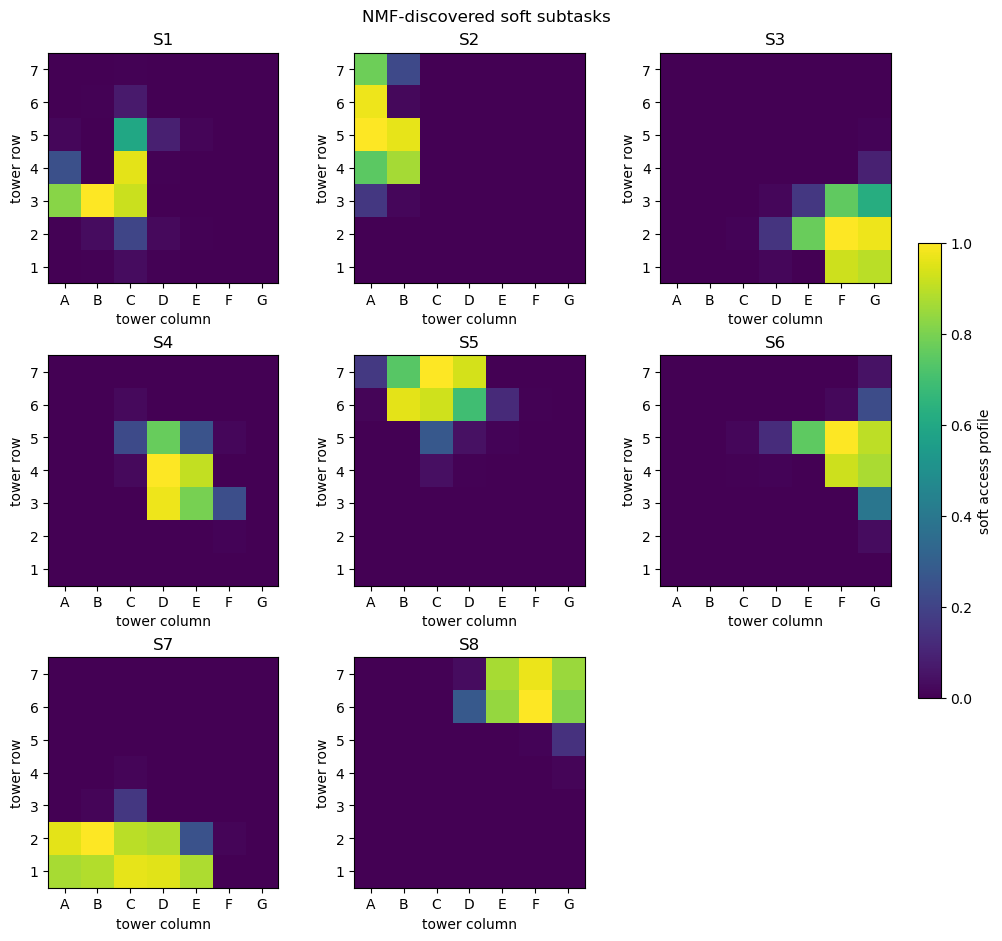

active fitted parameters: ('interior_reward', 'goal_reward', 'lower_control_cost', 'upper_control_cost', 'alpha', 'beta', 'core_threshold', 'core_exponent')


In [21]:
import numpy as np
from andrew_mlmdp.hierarchy import sample_hierarchical_rollouts

DISCOVERY_RANK = 8
SMOOTHNESS_STRENGTH = 50
DISCOVERY_SEED = 0

soft_discovery = discover_soft_subgoals(
    environment,
    ranks=(DISCOVERY_RANK,),
    parameters=NMFDiscoveryParameters(
        lambda_smooth=SMOOTHNESS_STRENGTH,
    ),
    seed=DISCOVERY_SEED,
).result(DISCOVERY_RANK)
viz.plot_soft_subtasks(soft_discovery)
plt.show()

soft_basis = SubgoalBasis.from_profiles(
    maze,
    soft_discovery.profiles,
    core_threshold=0.8,
)
initial_hierarchy_template = environment.hierarchy(
    soft_basis,
    parameters=soft_hierarchy_parameters(
        DISCOVERY_RANK,
        upper_control_cost=0.18,
    ),
)

print(
    "active fitted parameters:",
    required_hierarchical_parameter_names(initial_hierarchy_template),
)


## 4. Fit the hierarchy with Adam

As in the original workflow, trials with nonfinite likelihood under the initial hierarchy are excluded before optimization. Every parameter active for this distributed gated basis is fitted. The callback updates one in-place progress display rather than emitting one line per step.


In [22]:
initial_hierarchical_report = movement_dataset.report(
    score_hierarchical_movement_dataset(
        initial_hierarchy_template,
        movement_trials,
    )
)
finite_trial_keys = {
    (score.session_id, score.trial_id)
    for score in initial_hierarchical_report.result.trial_likelihoods
    if math.isfinite(score.log_likelihood)
}
fitting_trials = tuple(
    trial
    for trial in movement_trials
    if (trial.session_id, trial.trial_id) in finite_trial_keys
)
omitted_trial_count = len(movement_trials) - len(fitting_trials)

print(f"fitting trials: {len(fitting_trials)}")
print(f"omitted nonfinite initial trials: {omitted_trial_count}")
if not fitting_trials:
    raise RuntimeError("No trials have a finite initial hierarchy likelihood")


fitting trials: 522
omitted nonfinite initial trials: 0


In [23]:
FIT_LEARNING_RATE = 8e-2
FIT_MAX_STEPS = 1000
FIT_RELATIVE_TOLERANCE = 1e-4
FIT_PATIENCE = 20
FIT_LR_DECAY_FACTOR = 0.3
FIT_LR_DECAY_PATIENCE = 7
FIT_MINIMUM_LEARNING_RATE = 1e-4
FIT_SCHEDULER_RELATIVE_THRESHOLD = 3e-4

progress_display = display(
    "Waiting for first Adam evaluation...",
    display_id=True,
)

def show_fit_progress(evaluation):
    completed = min(evaluation.updates_completed, FIT_MAX_STEPS)
    fraction = completed / max(1, FIT_MAX_STEPS)
    filled = round(30 * fraction)
    bar = "█" * filled + "·" * (30 - filled)
    best_loss = evaluation.best_loss
    best_loss_text = "n/a" if best_loss is None else f"{best_loss:.6f}"
    progress_display.update(
        f"[{bar}] {completed}/{FIT_MAX_STEPS} Adam updates | "
        f"loss={evaluation.loss:.6f} | best={best_loss_text} | "
        f"lr={evaluation.learning_rate:.3e} | "
        f"gradient norm={evaluation.gradient_norm:.3e}"
    )

fit_parameter_names = required_hierarchical_parameter_names(
    initial_hierarchy_template
)
fit_result = initial_hierarchy_template.fit_parameters(
    fitting_trials,
    parameter_names=fit_parameter_names,
    learning_rate=FIT_LEARNING_RATE,
    max_steps=FIT_MAX_STEPS,
    relative_tolerance=FIT_RELATIVE_TOLERANCE,
    patience=FIT_PATIENCE,
    learning_rate_decay_factor=FIT_LR_DECAY_FACTOR,
    learning_rate_decay_patience=FIT_LR_DECAY_PATIENCE,
    minimum_learning_rate=FIT_MINIMUM_LEARNING_RATE,
    scheduler_relative_threshold=FIT_SCHEDULER_RELATIVE_THRESHOLD,
    progress_callback=show_fit_progress,
)
if fit_result.best_parameter_values is None:
    raise RuntimeError(
        "Parameter fitting ended before finding a finite state: "
        f"{fit_result.termination_reason}"
    )

optimal_parameter_values = dict(
    fit_result.best_parameter_values.as_floats()
)
finite_evaluations = [
    evaluation
    for evaluation in fit_result.history
    if math.isfinite(evaluation.loss)
]
best_evaluation = min(finite_evaluations, key=lambda item: item.loss)
fit_summary = pd.DataFrame(
    [
        {
            "fitted_trials": len(fitting_trials),
            "omitted_initial_nonfinite": omitted_trial_count,
            "optimizer_updates": fit_result.updates_completed,
            "termination_reason": fit_result.termination_reason,
            "converged": fit_result.converged,
            "initial_total_log_likelihood": (
                fit_result.history[0].total_log_likelihood
            ),
            "best_total_log_likelihood": (
                best_evaluation.total_log_likelihood
            ),
        }
    ]
)
parameter_table = pd.DataFrame(
    {
        "initial_value": pd.Series(
            fit_result.initial_parameter_values.as_floats()
        ),
        "optimal_value": pd.Series(optimal_parameter_values),
    }
).rename_axis("parameter")

display(fit_summary)
display(parameter_table)


'Waiting for first Adam evaluation...'

KeyboardInterrupt: 

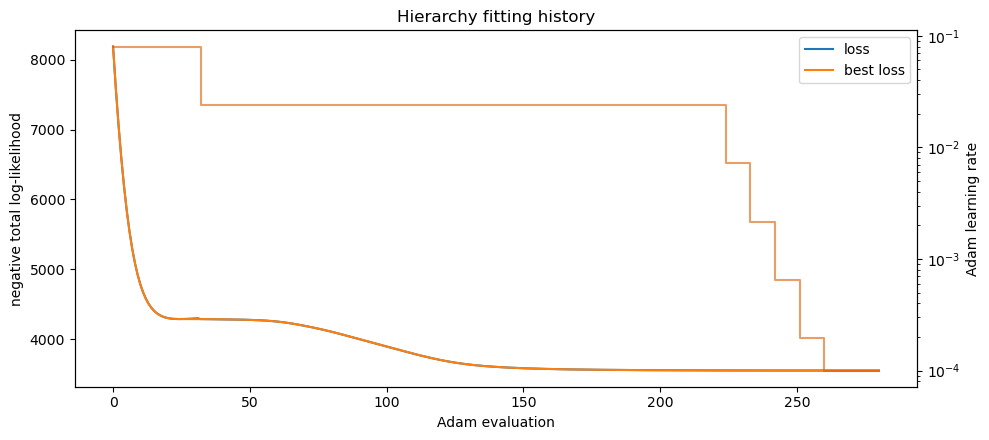

In [9]:
fit_history = pd.DataFrame(
    {
        "evaluation": [item.evaluation for item in fit_result.history],
        "loss": [item.loss for item in fit_result.history],
        "best_loss": [item.best_loss for item in fit_result.history],
        "learning_rate": [
            item.learning_rate for item in fit_result.history
        ],
    }
)
fig, loss_ax = plt.subplots(figsize=(10, 4.5))
loss_ax.plot(fit_history["evaluation"], fit_history["loss"], label="loss")
loss_ax.plot(
    fit_history["evaluation"],
    fit_history["best_loss"],
    label="best loss",
)
loss_ax.set_xlabel("Adam evaluation")
loss_ax.set_ylabel("negative total log-likelihood")
loss_ax.legend(loc="upper right")
learning_rate_ax = loss_ax.twinx()
learning_rate_ax.step(
    fit_history["evaluation"],
    fit_history["learning_rate"],
    color="#d95f02",
    alpha=0.6,
    where="post",
)
learning_rate_ax.set_yscale("log")
learning_rate_ax.set_ylabel("Adam learning rate")
loss_ax.set_title("Hierarchy fitting history")
fig.tight_layout()
plt.show()


## 5. Materialize the best fit as a fresh hierarchy

`fit_parameters` deliberately leaves the original template unchanged. The best snapshot is therefore used to rebuild the gated basis and the model parameters explicitly. All following diagnostics consume this fresh fitted hierarchy.


In [10]:
fitted_basis = SubgoalBasis.from_profiles(
    maze,
    soft_basis.profiles,
    core_threshold=optimal_parameter_values["core_threshold"],
    core_exponent=optimal_parameter_values["core_exponent"],
    labels=soft_basis.labels,
)
fitted_parameters = soft_hierarchy_parameters(
    DISCOVERY_RANK,
    **optimal_parameter_values,
)
fitted_hierarchy_template = environment.hierarchy(
    fitted_basis,
    parameters=fitted_parameters,
    task_library=initial_hierarchy_template.task_library,
    composition_exponent=initial_hierarchy_template.composition_exponent,
    composition_mode=initial_hierarchy_template.composition_mode,
)

EXAMPLE_TRIAL_INDEX = 0
example_trial = fitting_trials[EXAMPLE_TRIAL_INDEX]
example_start = example_trial.trajectory[0]
example_goal = example_trial.goal
fitted_task = fitted_hierarchy_template.for_goal(example_goal)

print(
    f"visualized trial: {example_trial.session_id}, "
    f"trial {example_trial.trial_id}"
)
print(f"start: {example_start}; goal: {example_goal}")
print(f"subgoals: {fitted_task.number_of_subtasks}")


visualized trial: m2/2022-06-28.maze, trial 1
start: (4, 0); goal: (0, 2)
subgoals: 8


## 6. Inspect the fitted access representations and upper dynamics

The first figure keeps the original NMF profiles, gated profiles, and task-level execution-access probabilities distinct. The second compares passive and fitted goal-conditioned controlled upper dynamics from the selected physical start.


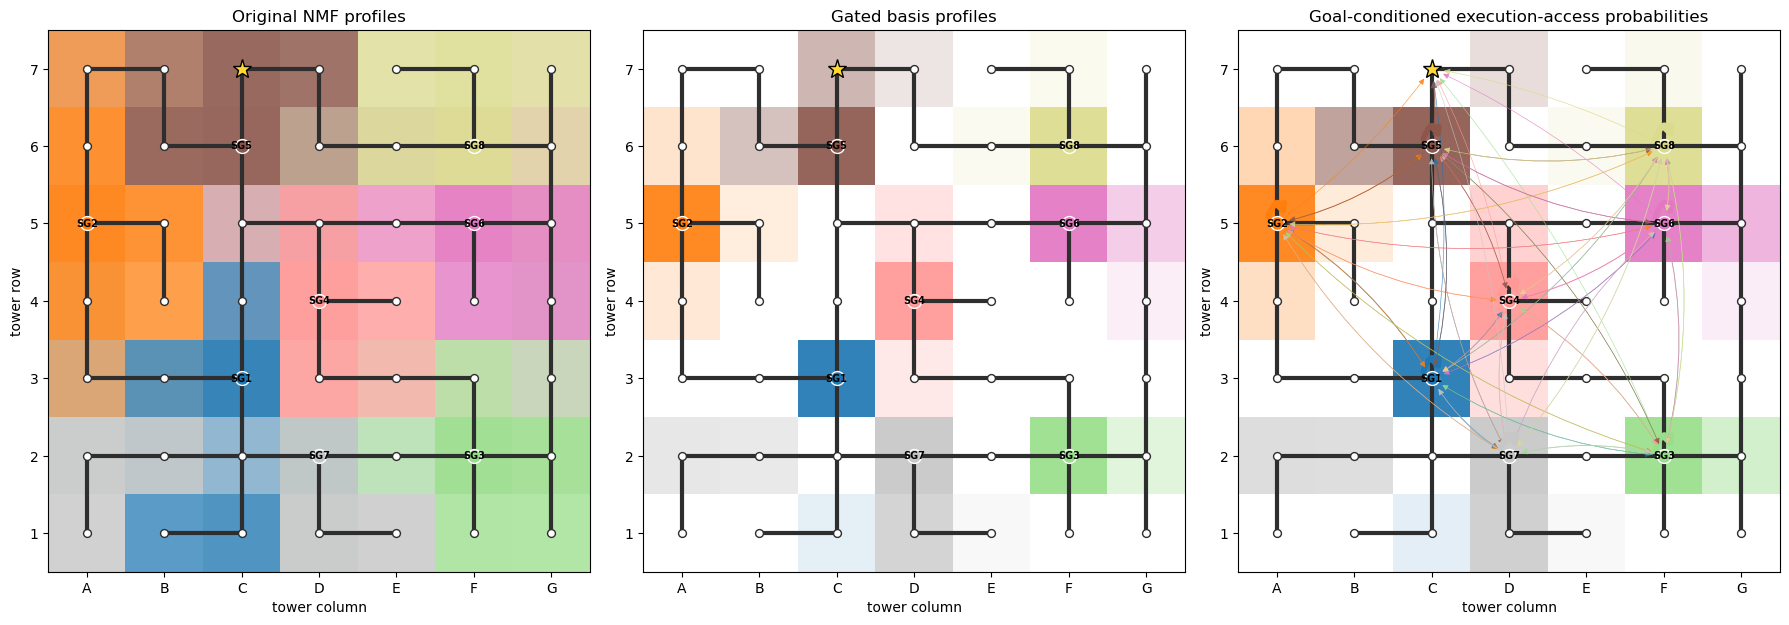

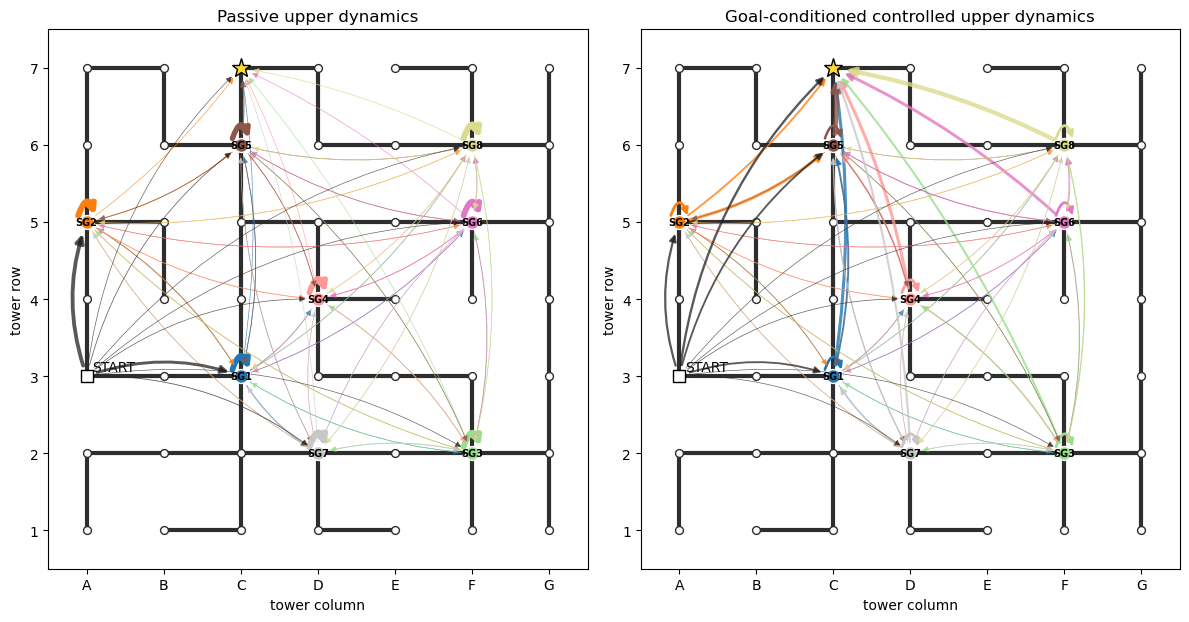

In [11]:
fig, axes = viz.plot_subgoal_access_and_upper_dynamics(
    fitted_task,
    show_original_profiles=True,
    show_gated_profiles=True,
)
plt.show()

fig, axes = viz.plot_upper_controlled_dynamics(
    fitted_task,
    start_state=example_start,
    compare_passive=True,
)
plt.show()


## 7. Inspect fitted continuation policies and refractory departures

Each representative coordinate below is selected only from positive task-level execution-access support. It is passed explicitly as an entry coordinate so the purple arrow shows the actual first post-access refractory-adjusted distribution; display peaks are never treated as entry states.


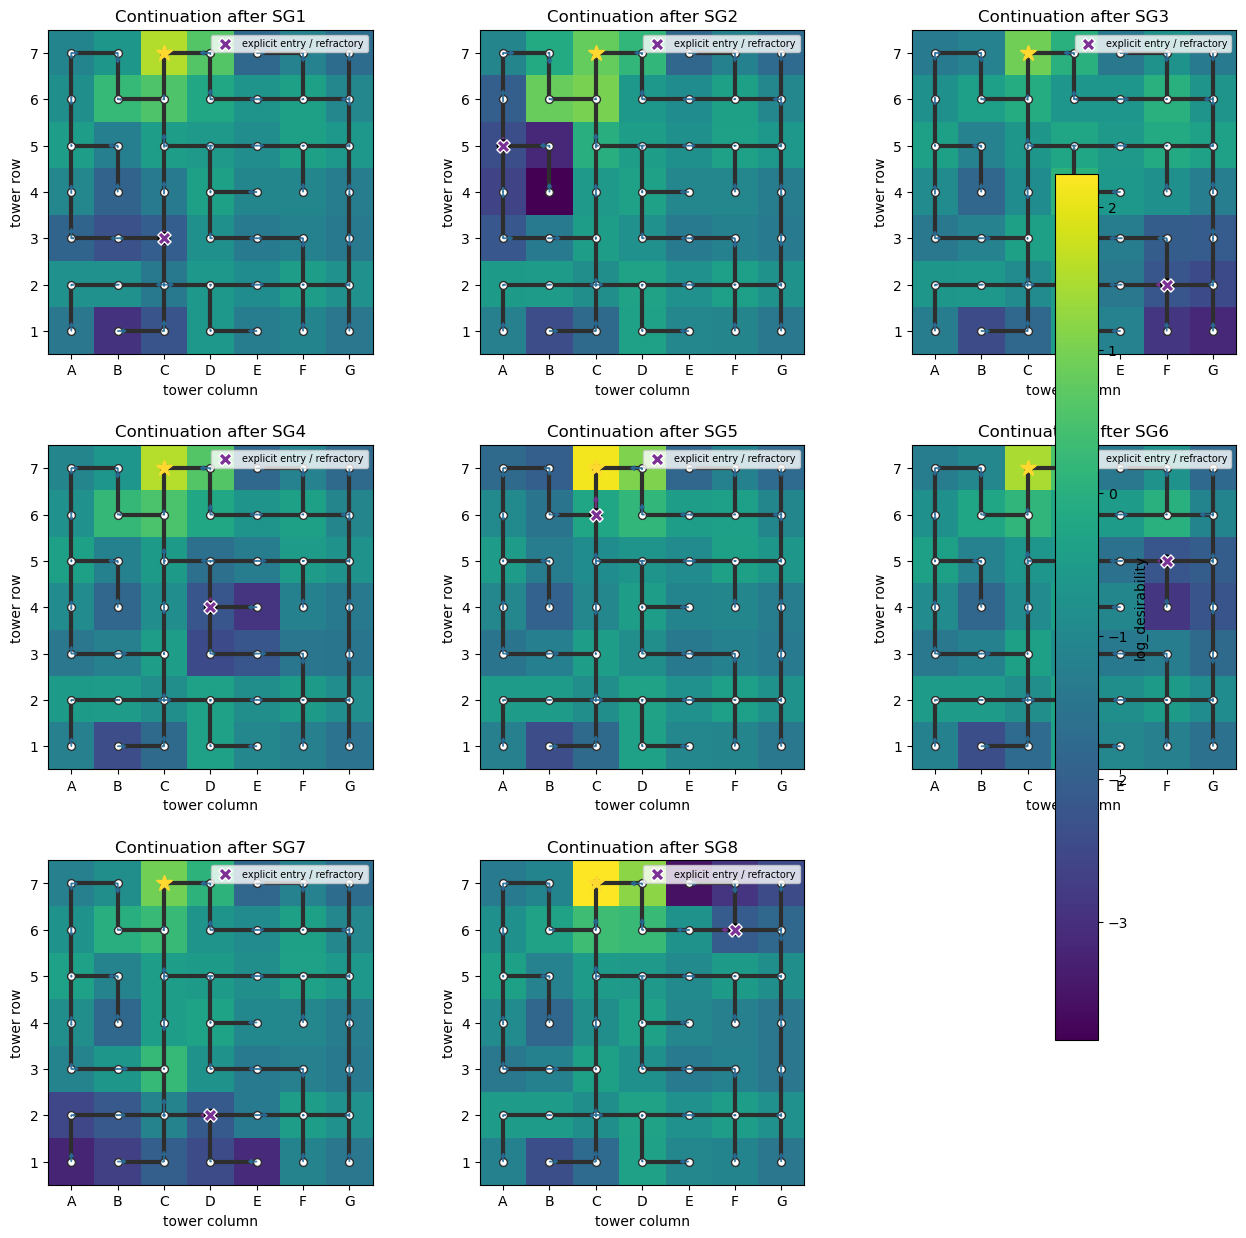

In [12]:
entry_coordinates = {}
for subgoal_index in range(fitted_task.number_of_subtasks):
    access_probabilities = fitted_task.lower_subtask_passive[subgoal_index]
    interior_index = int(np.argmax(access_probabilities))
    if access_probabilities[interior_index] > 0.0:
        physical_state = int(fitted_task.interior_states[interior_index])
        entry_coordinates[subgoal_index] = maze.coordinate(physical_state)

fig, axes = viz.plot_continuation_policies(
    fitted_task,
    quantity="log_desirability",
    entry_coordinates=entry_coordinates,
    show_refractory=True,
)
plt.show()


## 8. Inspect the fitted initial composition pipeline

These panels show the exact internal `raw_weights → composition_input_weights → weights` pipeline for the selected start state, with the physical-goal component separated.


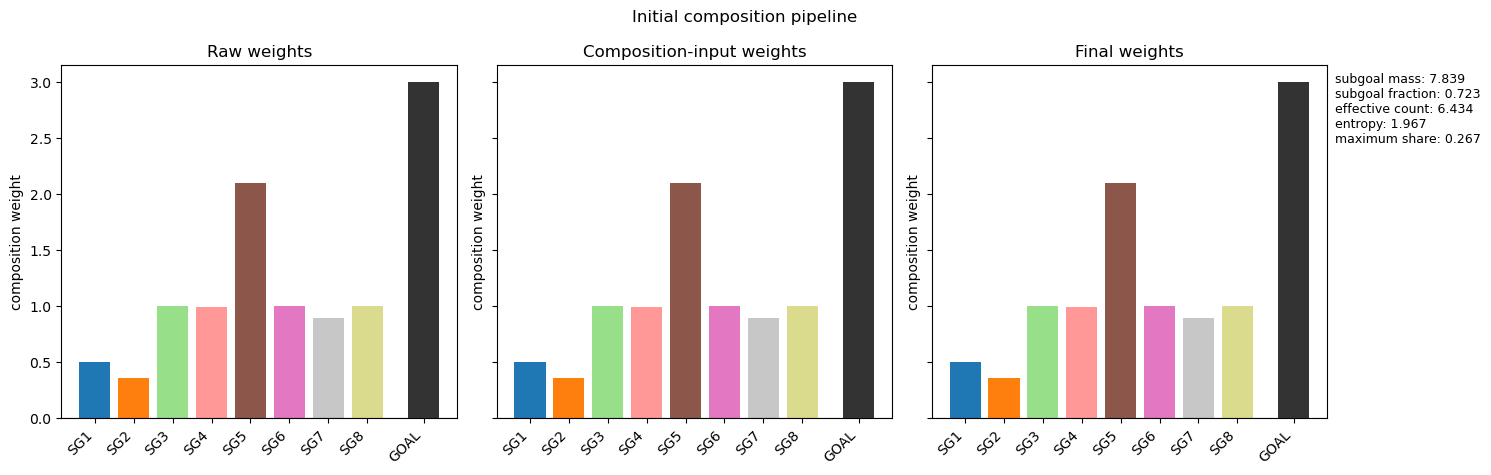

In [13]:
fig, axes = viz.plot_composition_weights(
    fitted_task,
    start_state=example_start,
)
plt.show()


## 9. Compare fitted physical and latent rollout distributions

One seeded rollout ensemble drives both figures. Physical trajectory lengths are measured as physical steps only. The observed comparison uses every fitted trial with the same start and goal as the selected trial, so model and data are in identical per-rollout units.


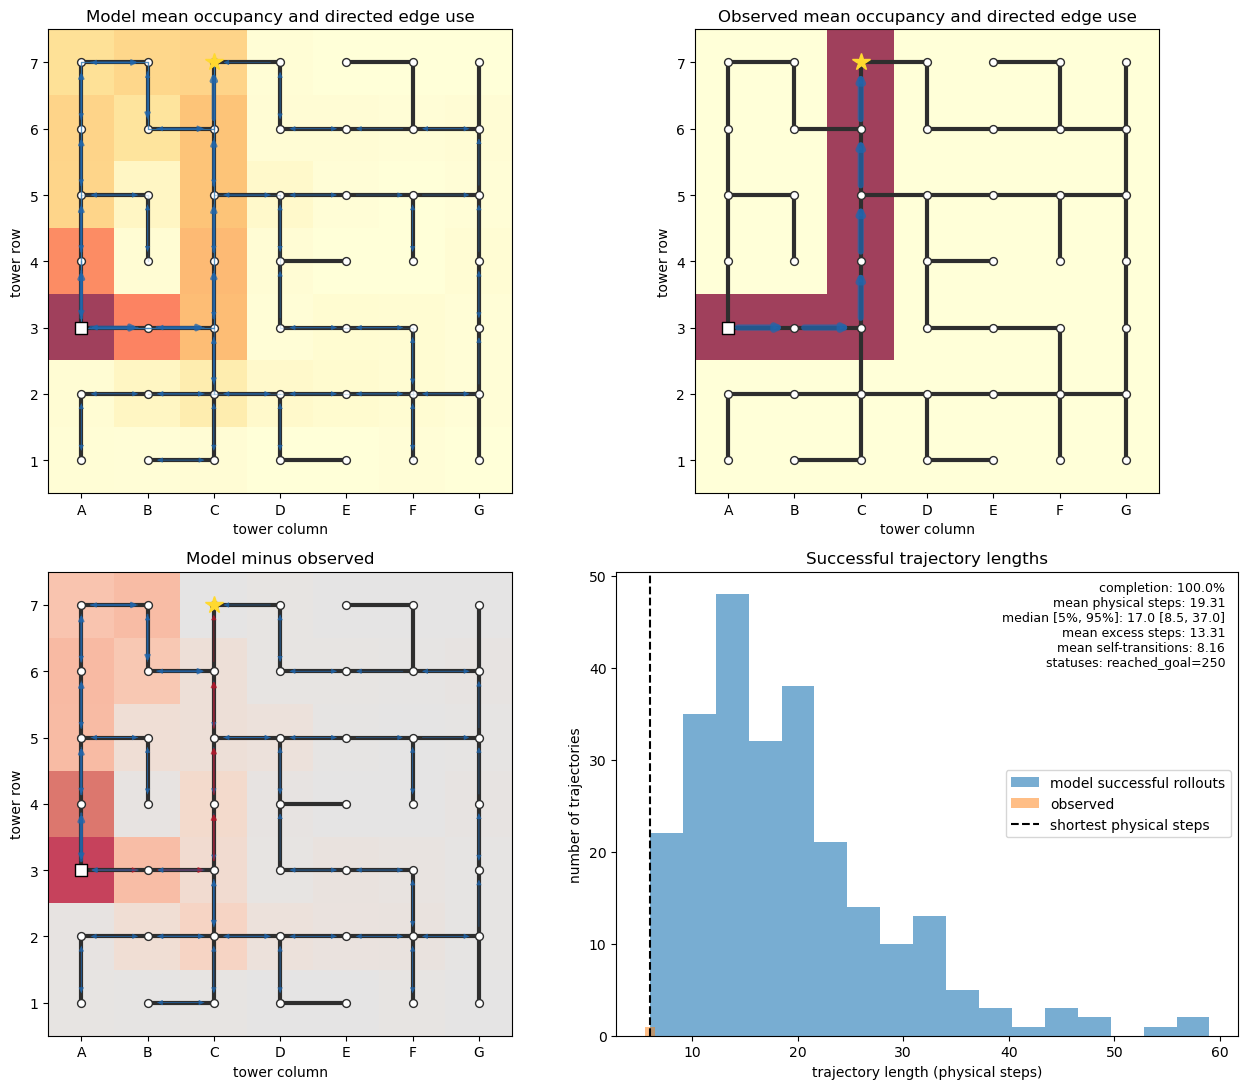

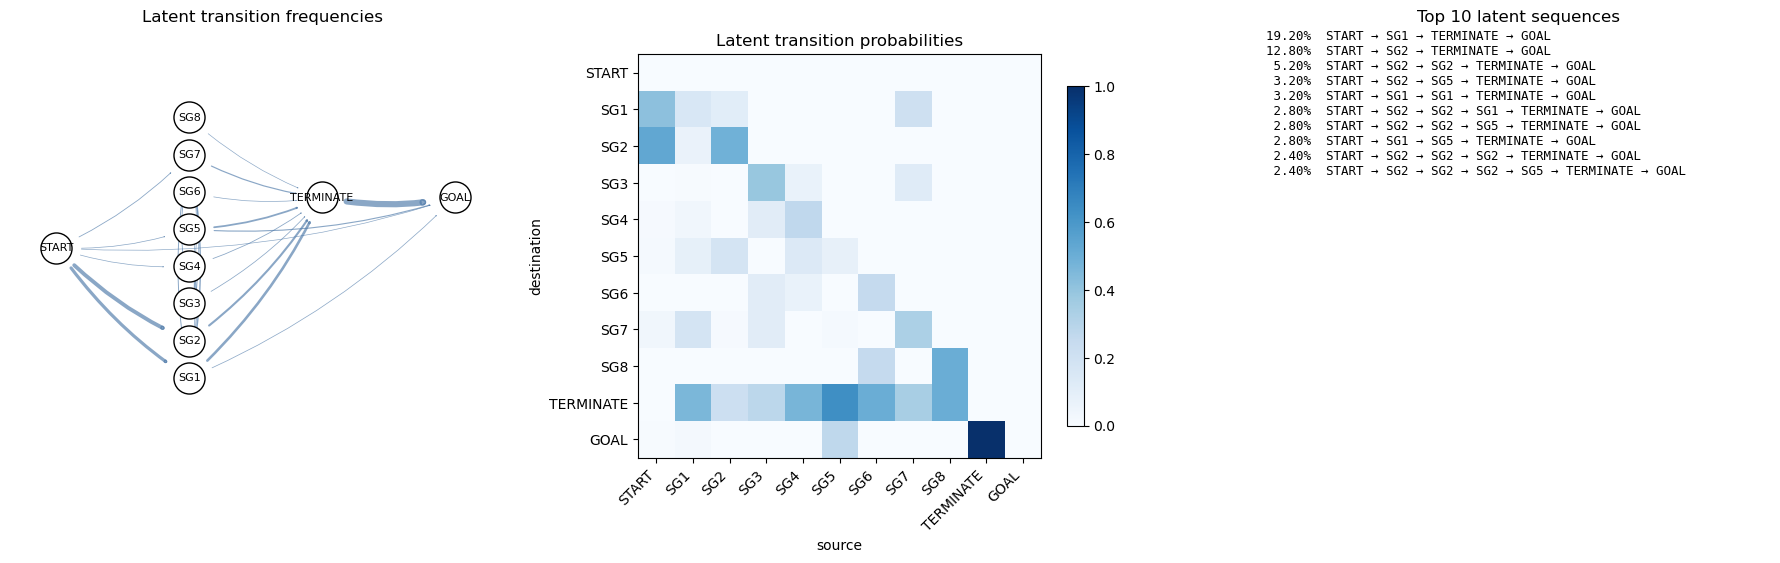

In [14]:
ROLLOUT_COUNT = 250
ROLLOUT_SEED = 7

rollout_ensemble = sample_hierarchical_rollouts(
    fitted_task,
    example_start,
    n_rollouts=ROLLOUT_COUNT,
    seed=ROLLOUT_SEED,
    max_steps=500,
)
matching_observed_trajectories = tuple(
    trial.trajectory
    for trial in fitting_trials
    if trial.trajectory[0] == example_start and trial.goal == example_goal
)

fig, axes = viz.plot_rollout_distribution(
    fitted_task,
    example_start,
    ensemble=rollout_ensemble,
    observed_trajectories=matching_observed_trajectories,
)
plt.show()

fig, axes = viz.plot_rollout_subgoal_sequences(
    fitted_task,
    example_start,
    ensemble=rollout_ensemble,
    top_n=10,
)
plt.show()
